In [ ]:
import osmnx as ox
import geopandas as gpd
import requests
import zipfile
import os
import pandas as pd
from rasterstats import zonal_stats

Downloading West Virginia boundary

In [4]:
WV_FIPS = "54"
url = f"https://www2.census.gov/geo/tiger/TIGER2023/STATE/tl_2023_us_state.zip"
os.makedirs("../data/raw", exist_ok=True)

print("Downloading Census state boundaries...")
r = requests.get(url, stream=True)
with open("../data/raw/states.zip", "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

with zipfile.ZipFile("../data/raw/states.zip", "r") as z:
    z.extractall("../data/raw/states/")

states = gpd.read_file("../data/raw/states/tl_2023_us_state.shp")
wv = states[states["STATEFP"] == WV_FIPS].copy()
wv = wv.to_crs(epsg=4326)
print(f"WV boundary loaded. CRS: {wv.crs}")

WV boundary loaded. CRS: EPSG:4326


Exploring the Data

In [5]:
print(states.head())
# shows columns, sample rows, structure of dataset

  REGION DIVISION STATEFP   STATENS GEOID      GEOIDFQ STUSPS           NAME  \
0      3        5      54  01779805    54  0400000US54     WV  West Virginia   
1      3        5      12  00294478    12  0400000US12     FL        Florida   
2      2        3      17  01779784    17  0400000US17     IL       Illinois   
3      2        4      27  00662849    27  0400000US27     MN      Minnesota   
4      3        5      24  01714934    24  0400000US24     MD       Maryland   

  LSAD  MTFCC FUNCSTAT         ALAND       AWATER     INTPTLAT      INTPTLON  \
0   00  G4000        A   62266499712    489003081  +38.6472854  -080.6183274   
1   00  G4000        A  138963763779  45970528648  +28.3989775  -082.5143005   
2   00  G4000        A  143778366814   6216688589  +40.1028754  -089.1526108   
3   00  G4000        A  206244555303  18937471947  +46.3159573  -094.1996043   
4   00  G4000        A   25151736098   6979330958  +38.9466584  -076.6744939   

                                      

In [6]:
print(states.columns) # what attributes exist (STATEFP, NAME, geometry, etc.)
print(states.crs) # coordinate system
print(states.shape) # number of rows + columns

Index(['REGION', 'DIVISION', 'STATEFP', 'STATENS', 'GEOID', 'GEOIDFQ',
       'STUSPS', 'NAME', 'LSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER',
       'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='str')
EPSG:4269
(56, 16)


In [7]:
# checking WV
print(wv)
print(wv.iloc[0])

  REGION DIVISION STATEFP   STATENS GEOID      GEOIDFQ STUSPS           NAME  \
0      3        5      54  01779805    54  0400000US54     WV  West Virginia   

  LSAD  MTFCC FUNCSTAT        ALAND     AWATER     INTPTLAT      INTPTLON  \
0   00  G4000        A  62266499712  489003081  +38.6472854  -080.6183274   

                                            geometry  
0  POLYGON ((-77.75438 39.33346, -77.75422 39.333...  
REGION                                                      3
DIVISION                                                    5
STATEFP                                                    54
STATENS                                              01779805
GEOID                                                      54
GEOIDFQ                                           0400000US54
STUSPS                                                     WV
NAME                                            West Virginia
LSAD                                                       00
MTFCC           

<Axes: >

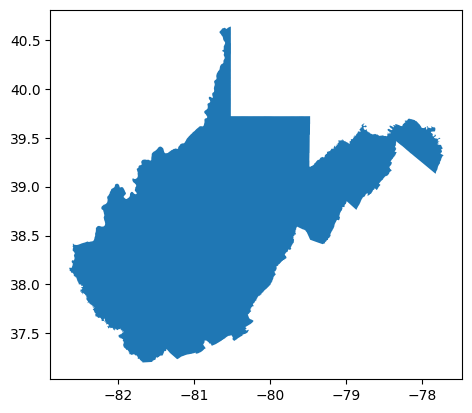

In [8]:
wv.plot()

In [9]:
# wv.info()
# wv.head()
# wv.plot()

In [10]:
# import folium
# from IPython.display import HTML
# from IPython.display import display

# # Step 1: project to a metric CRS for correct centroid calculation
# wv_projected = wv.to_crs(epsg=3857)

# # Step 2: compute centroid in projected CRS, then convert back to lat/lon
# centroid = wv_projected.geometry.centroid.to_crs(epsg=4326).values[0]

# center = [centroid.y, centroid.x]

# # Step 3: create folium map (must use EPSG:4326)
# m = folium.Map(location=center, zoom_start=7)

# # Step 4: ensure GeoJSON is also in EPSG:4326
# folium.GeoJson(wv.to_crs(epsg=4326)).add_to(m)

# HTML(m._repr_html_())
# display(m)

In [11]:
# Save
wv.to_file("../data/processed/wv_boundary.gpkg", layer="boundary", driver="GPKG")
print("Saved: data/processed/wv_boundary.gpkg")

Saved: data/processed/wv_boundary.gpkg


Downloading county boundaries

In [12]:
url_counties = "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip"
r2 = requests.get(url_counties, stream=True)
with open("../data/raw/counties.zip", "wb") as f:
    for chunk in r2.iter_content(chunk_size=8192):
        f.write(chunk)

with zipfile.ZipFile("../data/raw/counties.zip", "r") as z:
    z.extractall("../data/raw/counties/")

counties = gpd.read_file("../data/raw/counties/tl_2023_us_county.shp")
wv_counties = counties[counties["STATEFP"] == WV_FIPS].copy()
wv_counties = wv_counties.to_crs(epsg=4326)
print(f"WV counties loaded: {len(wv_counties)} counties")

wv_counties.to_file("../data/processed/wv_counties.gpkg", layer="counties", driver="GPKG")
print("Saved: data/processed/wv_counties.gpkg")

WV counties loaded: 55 counties
Saved: data/processed/wv_counties.gpkg


<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 55 entries, 37 to 3234
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   STATEFP   55 non-null     str     
 1   COUNTYFP  55 non-null     str     
 2   COUNTYNS  55 non-null     str     
 3   GEOID     55 non-null     str     
 4   GEOIDFQ   55 non-null     str     
 5   NAME      55 non-null     str     
 6   NAMELSAD  55 non-null     str     
 7   LSAD      55 non-null     str     
 8   CLASSFP   55 non-null     str     
 9   MTFCC     55 non-null     str     
 10  CSAFP     18 non-null     str     
 11  CBSAFP    27 non-null     str     
 12  METDIVFP  1 non-null      str     
 13  FUNCSTAT  55 non-null     str     
 14  ALAND     55 non-null     int64   
 15  AWATER    55 non-null     int64   
 16  INTPTLAT  55 non-null     str     
 17  INTPTLON  55 non-null     str     
 18  geometry  55 non-null     geometry
dtypes: geometry(1), int64(2), str(16)
memory usage

<Axes: >

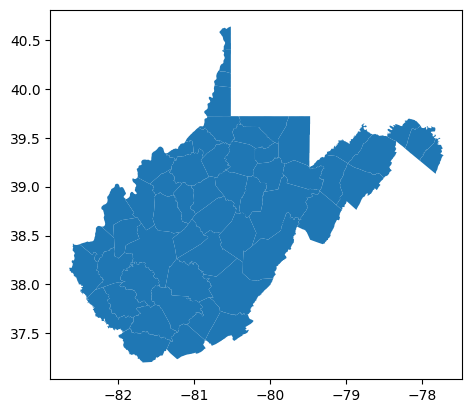

In [13]:
wv_counties.info()
wv_counties.head(5)
wv_counties.plot()


Downloading roads via OSMnx

In [ ]:
# 1. Define the counties of West Virginia
counties_list = (wv_counties["NAMELSAD"] + ", West Virginia").tolist()

all_county_roads = []

print("Starting localized downloads to prevent crashes...")

for county in counties_list:
    try:
        print(f"Downloading: {county}")
        # We use a 2-minute timeout per county to be safe
        ox.settings.timeout = 120
        
        # Download graph and convert to GeoDataFrame
        G = ox.graph_from_place(county, network_type="drive", simplify=True)
        roads = ox.graph_to_gdfs(G, nodes=False, edges=True)
        
        # Keep only what we need to save memory
        roads = roads[["geometry", "highway", "length"]].copy()
        all_county_roads.append(roads)
        
    except Exception as e:
        print(f"Skipping {county} due to error: {e}")

# 2. Combine all pieces
if all_county_roads:
    print("Combining all counties into one file...")
    wv_roads = pd.concat(all_county_roads, ignore_index=True)
    
    # 3. Save to your path
    output_path = "../data/processed/wv_roads.gpkg"
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    wv_roads.to_file(output_path, layer="roads", driver="GPKG")
    print(f"Done! Saved {len(wv_roads)} segments to {output_path}")
else:
    print("No data was collected.")

Starting localized downloads to prevent crashes...
Downloading: Pocahontas County, West Virginia
Downloading: Putnam County, West Virginia
Downloading: Wetzel County, West Virginia
Downloading: Boone County, West Virginia
Downloading: Cabell County, West Virginia
Downloading: Marshall County, West Virginia
Downloading: Jackson County, West Virginia
Downloading: Monongalia County, West Virginia
Downloading: Mineral County, West Virginia
Downloading: Hancock County, West Virginia
Downloading: Preston County, West Virginia
Downloading: Hardy County, West Virginia
Downloading: Wood County, West Virginia
Downloading: Webster County, West Virginia
Downloading: Hampshire County, West Virginia
Downloading: McDowell County, West Virginia
Downloading: Harrison County, West Virginia
Downloading: Barbour County, West Virginia
Downloading: Tucker County, West Virginia
Downloading: Clay County, West Virginia
Downloading: Logan County, West Virginia
Downloading: Pleasants County, West Virginia
Downlo

Downloading telecom/communication lines from OSM

In [15]:
print("Pulling telecom infrastructure from OpenStreetMap...")
tags = {
    "communication": True,
    "man_made": ["communications_tower", "mast"],
    "tower:type": "communication"
}

try:
    telecom = ox.features_from_place("West Virginia, USA", tags=tags)
    telecom = telecom.to_crs(epsg=4326)
    print(f"Telecom features found: {len(telecom)}")
    print(f"Feature types:\n{telecom.geometry.geom_type.value_counts()}")

    # Document the messiness
    print(f"\nData quality notes:")
    print(f"  - Columns available: {list(telecom.columns[:10])}")
    print(f"  - Null counts in key fields:")
    for col in ["name", "operator", "communication"]:
        if col in telecom.columns:
            print(f"    {col}: {telecom[col].isna().sum()} nulls out of {len(telecom)}")

    telecom.to_file("../data/processed/wv_telecom.gpkg", layer="telecom", driver="GPKG")
    print("Saved: data/processed/wv_telecom.gpkg")

except Exception as e:
    print(f"Note: Limited telecom data in OSM for WV: {e}")
    print("This is expected — OSM telecom coverage in rural WV is sparse.")
    print("We will use road network as infrastructure proxy in analysis.")

Pulling telecom infrastructure from OpenStreetMap...


/workspaces/wv-broadband-gap/venv/lib/python3.12/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 37 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Telecom features found: 1239
Feature types:
Point         1224
Polygon         10
LineString       5
Name: count, dtype: int64

Data quality notes:
  - Columns available: ['geometry', 'communication:radio', 'ele', 'gnis:feature_id', 'man_made', 'name', 'tower:construction', 'tower:type', 'communication:mobile_phone', 'frequency']
  - Null counts in key fields:
    name: 1198 nulls out of 1239
    operator: 1224 nulls out of 1239
    communication: 1232 nulls out of 1239
Saved: data/processed/wv_telecom.gpkg


Download FCC broadband data

In [20]:
# FCC Broadband Data Collection - fabric availability data
# Direct download of WV state file
print("Downloading FCC broadband availability data for WV...")
fcc_url = "https://broadbandmap.fcc.gov/api/public/map/downloads/availability_by_state?state_code=WV&file_type=csv"

print("Note: FCC data requires manual download.")
print("Go to: https://broadbandmap.fcc.gov/data-download")
print("Select: West Virginia > Fixed Broadband > Download")
print("Save to: data/raw/fcc/all_technologies.csv")


Note: FCC data requires manual download.
Go to: https://broadbandmap.fcc.gov/data-download
Select: West Virginia > Fixed Broadband > Download
Save to: data/raw/fcc/all_technologies.csv


In [17]:
import pandas as pd
import os

data_dir = "../data/raw/fcc"

files = {
    "Fiber": "fiber.csv",
    "Cable": "cable.csv",
    "Copper": "copper.csv",
    "LBR Fixed Wireless": "lbr_fixed_wireless.csv",
    "Licensed Fixed Wireless": "licensed_fixed_wireless.csv",
    "Unlicensed Fixed Wireless": "unlicensed_fixed_wireless.csv",
    "NGSO": "ngso.csv"
}

dfs = []

for tech, file in files.items():
    path = os.path.join(data_dir, file)
    
    if os.path.exists(path):
        df = pd.read_csv(path)
        df["technology"] = tech
        dfs.append(df)
        print(f"Loaded {file} -> {df.shape}")
    else:
        print(f"Missing: {path}")

# Combine everything
combined_df = pd.concat(dfs, ignore_index=True)

print("Final dataset shape:", combined_df.shape)
combined_df.head()

output_path = "../data/processed/fcc_wv_broadband.csv"
os.makedirs("../data/processed", exist_ok=True)

combined_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Loaded fiber.csv -> (381275, 12)
Loaded cable.csv -> (661411, 12)
Loaded copper.csv -> (168658, 12)
Loaded lbr_fixed_wireless.csv -> (12356, 12)
Loaded licensed_fixed_wireless.csv -> (1339110, 12)
Loaded unlicensed_fixed_wireless.csv -> (113363, 12)
Loaded ngso.csv -> (894686, 12)
Final dataset shape: (3570859, 12)
Saved to: ../data/processed/fcc_wv_broadband.csv


Download the WorldPop dataset for the US (or just WV)

In [5]:
raster_path = "../data/raw/usa_pop_1km.tif"

# Load your WV counties (the "cookie cutters")
# Ensure they are in the same CRS as WorldPop (EPSG:4326)
wv_counties = gpd.read_file("../data/processed/wv_counties.gpkg").to_crs(epsg=4326)

# Run the Zonal Statistics
print("Extracting population for WV counties...")
stats = zonal_stats(wv_counties, raster_path, stats="sum")

# Clean the data: Some counties might return 'None' if they are on the very edge
wv_counties['total_pop'] = [s['sum'] if s['sum'] is not None else 0 for s in stats]

print(wv_counties[['NAME', 'total_pop']].sort_values(by='total_pop', ascending=False).head())

Extracting population for WV counties...
          NAME      total_pop
51     Kanawha  163837.718750
39    Berkeley  136525.453125
7   Monongalia  111884.484375
4       Cabell   92388.046875
12        Wood   82806.625000


Final Check

In [21]:
print("Files created:")
for f in os.listdir("../data/processed"):
    path = f"data/processed/{f}"
    print(f"  {path}")

Files created:
  data/processed/wv_roads.gpkg
  data/processed/wv_boundary.gpkg
  data/processed/wv_counties.gpkg
  data/processed/fcc_wv_broadband.csv
  data/processed/wv_telecom.gpkg
  data/processed/west-virginia-260414.osm.pbf
